In [1]:
# -*- coding: utf-8 -*-
#  Copyright 2026 United Kingdom Research and Innovation
#
#  Licensed under the Apache License, Version 2.0 (the "License");
#  you may not use this file except in compliance with the License.
#  You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
#  Unless required by applicable law or agreed to in writing, software
#  distributed under the License is distributed on an "AS IS" BASIS,
#  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
#  See the License for the specific language governing permissions and
#  limitations under the License.
#
#   Authored by: Martin Sæbye Carøe (Technical University of Denmark, DTU Compute)

# Reconstruction with a Huber loss function data fidelity

This small user showcase shows the benefit of using the Huber loss function over for example a least squares data fidelity.

For $d \in \mathbb{R}$, define

$$
\phi_\delta(d) =
\begin{cases}
\frac{1}{2}*d^2, & \text{if } |d| \leq \delta, \\
\delta\left(|d| - \frac{1}{2}*\delta\right), & \text{otherwise}.
\end{cases}
$$

The `HuberLoss` is obtained by applying this function element-wise.

The function is continuously differentiable which makes it suited for optimization methods such as Gradient descent and FISTA. The gradient evaluation of a data fidelity term with the Huber loss is similar to that of the least squares loss function, but includes a "clipping" of gradient valeus larger than $\delta$ (and smaller than $-\delta$).

The Huber loss makes the optimization to outliers in the data. This notebook will show the effects of choosing different $\delta$-values.

The data used in this example is a 3D parallel-beam synchrotron dataset of a steel wire.

The notebook requires CIL > v26.0.0. At the time of writing, a version of CIL has not yet been released with Huber Loss in it, so CIL must be installed from the master branch.

In [2]:
import cil
print(cil.__version__)

26.0.1.dev5+g60b0a9022


### Import packages

In [1]:
# Import algorithms, operators and functions from CIL optimisation module
from cil.optimisation.algorithms import FISTA
from cil.optimisation.functions import IndicatorBox, LeastSquares
from cil.optimisation.functions.HuberLoss import HuberLoss

# Import CIL Processors for preprocessing
from cil.processors import CentreOfRotationCorrector, Slicer, TransmissionAbsorptionConverter

# Import CIL display function
from cil.utilities.display import show2D

# Import from CIL ASTRA plugin
from cil.plugins.astra import ProjectionOperator

# Import the islicer used for visualization
from cil.utilities.jupyter import islicer

# All external imports
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

### Load data + preprocessing

We load the dataset, which is included in CIL for demonstration purposes. We also do transmission-absoprtion conversion, and correct for the center of rotation offset. We also crop it.

In [2]:
# Load the example data set
from cil.utilities.dataexample import SYNCHROTRON_PARALLEL_BEAM_DATA
data_sync = SYNCHROTRON_PARALLEL_BEAM_DATA.get()

# Preprocessing
scale = data_sync.get_slice(vertical=20).mean()
data_sync = data_sync/scale
data_sync = TransmissionAbsorptionConverter()(data_sync)
data_sync = CentreOfRotationCorrector.xcorrelation(slice_index='centre')(data_sync)

# Crop data and reorder for ASTRA backend
data = Slicer(roi={'horizontal':(20,140,1)})(data_sync)

data.reorder(order='astra')

In [3]:
# Define custom parameters for show2D for visualizing all reconstructions consistently
sx = 44
sz = 103
ca1 = -0.01
ca2 =  0.11
slices = [('horizontal_x',sx),('vertical',sz)]

We extract the geometry from the data containers, and create a projection operator object.

In [4]:
ag = data.geometry
ig = ag.get_ImageGeometry()
A = ProjectionOperator(ig, ag, device="gpu")

In [5]:
islicer(data)

To do the minimization, we solve

\begin{equation}
\min_{x\geq 0} d(Ax, b),
\end{equation}

where 

$$ d(Ax,b)=\phi_\delta(Ax-b)= \begin{cases} \frac{1}{2}d^2, & \text{if } |d| \le \delta,\\[4pt] \delta\left(|d|-\frac{1}{2}\delta\right), & \text{otherwise} \end{cases} $$

applied elementwise,

or

$$d(Ax, b) = \|Ax-b\|^2_2$$

for comparison. 

In CIL the Huber Loss is implemented using the `HuberLoss Function`. It takes a forward operator $A$, measured data $b$, a `huber_delta` parameter $\delta$, optional weights, $w$,  and multiplicative constant, $c$. At a point, $x$, it evaluates:


$$
\operatorname{HuberLoss}_\delta(x)
=
c * \sum_i w_i \phi_\delta\left([Ax-b]_i\right).
$$

In our case we use the default weights and multiplicative constant (both default to 1), so set-up the Huber Loss using: `HuberLoss(A, data, huber_delta=delta)`

For this initial reconstruction, we set $\delta = 0.2$. We run FISTA for 100 iterations.

In [6]:
huber_delta = 0.2
F_least_squares = LeastSquares(A, data)
F_huber = HuberLoss(A,data,huber_delta)
G = IndicatorBox(lower=0.0)
x0 = ig.allocate(0.0)
FISTA_least_squares = FISTA(f=F_least_squares, 
                  g=G, 
                  initial=x0)


FISTA_huber = FISTA(f=F_huber, 
                  g=G, 
                  initial=x0)


FISTA_least_squares.run(100, verbose=1)

FISTA_huber.run(100, verbose=1)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

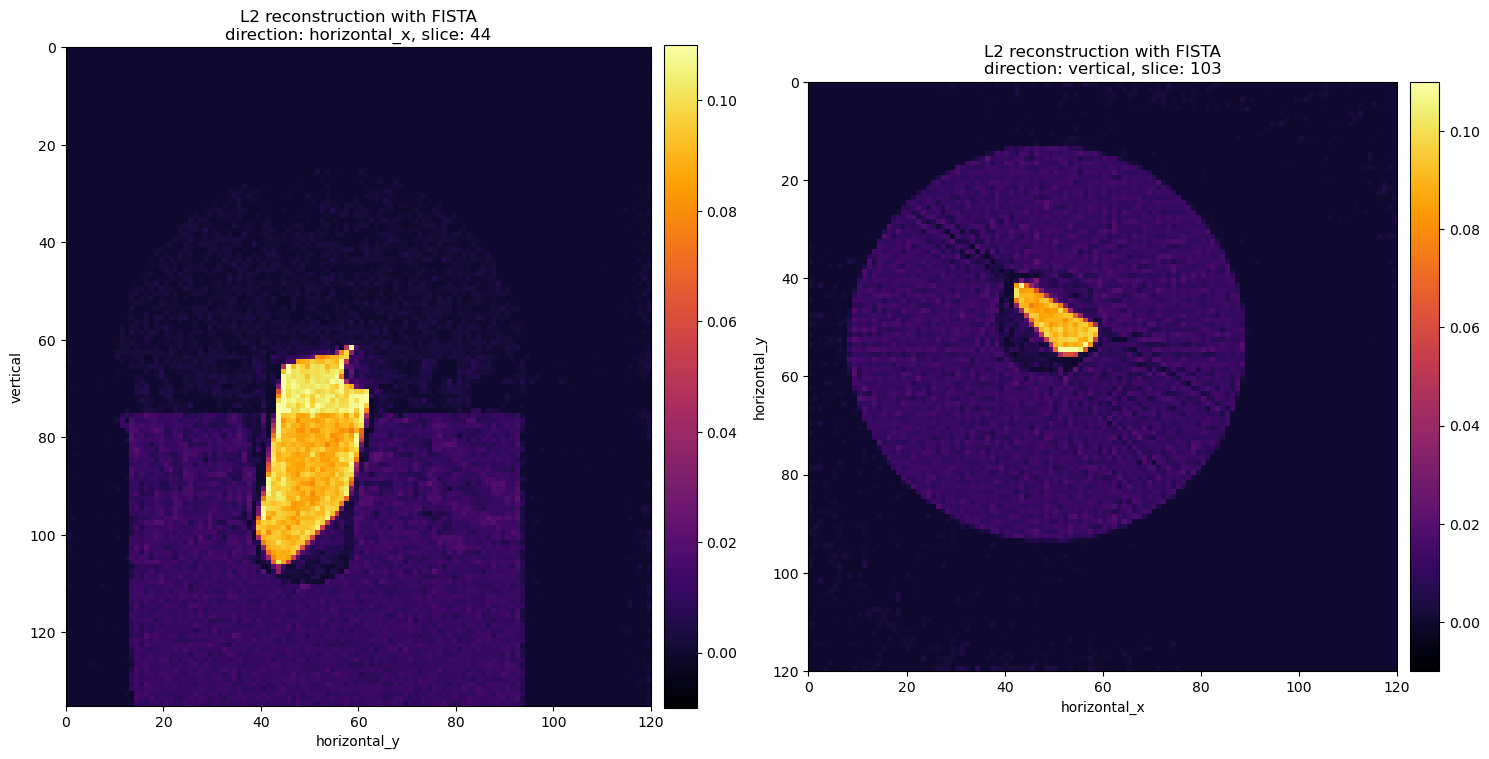

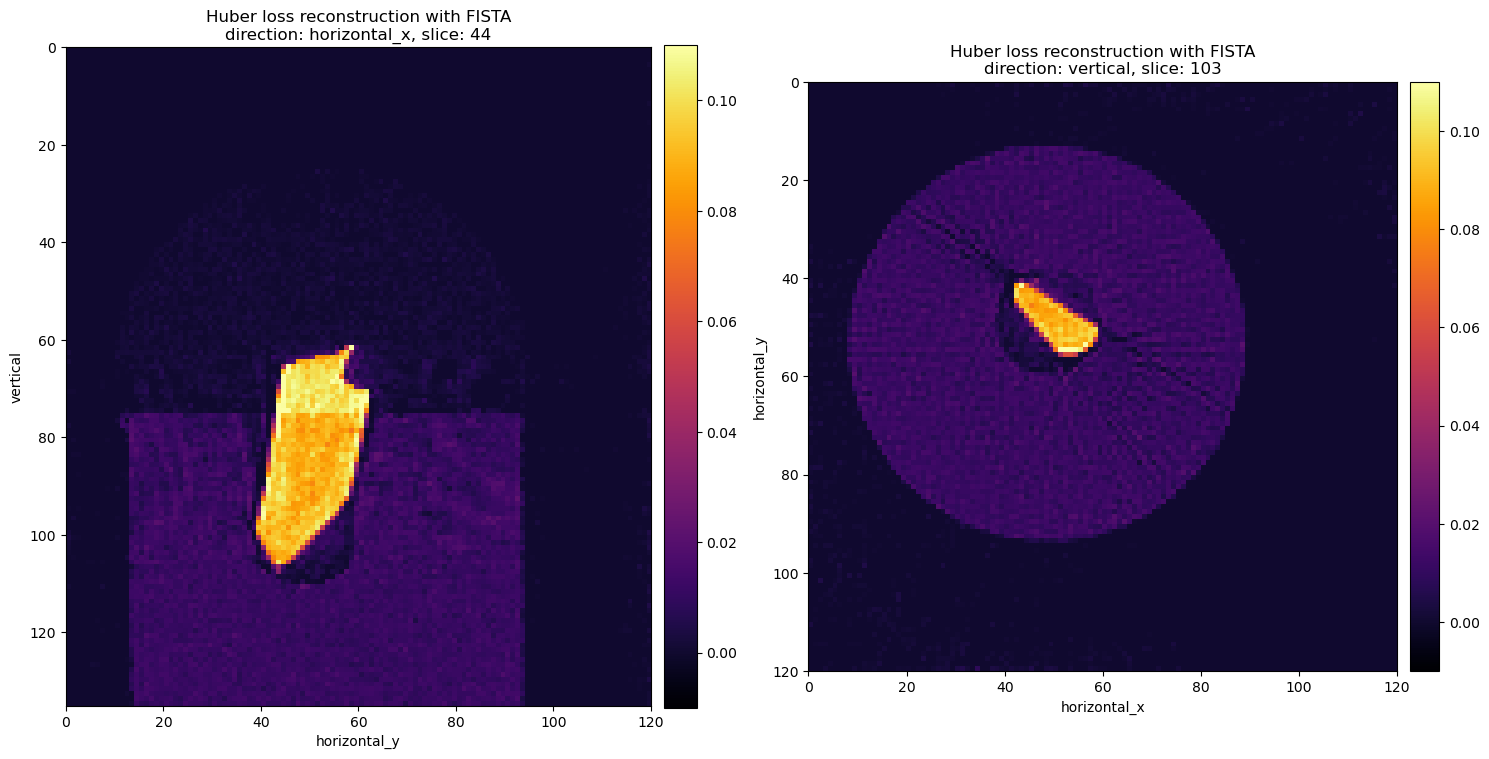

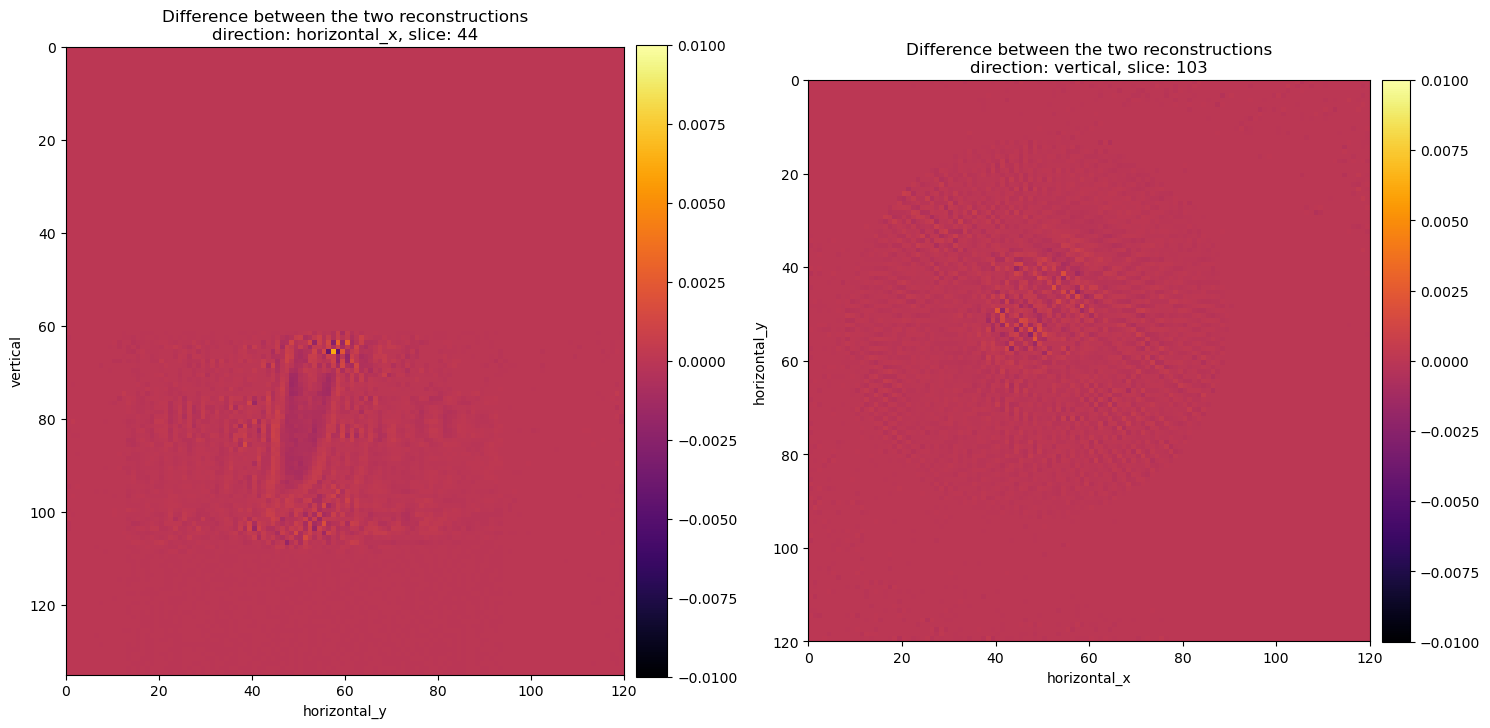

In [7]:


show2D(FISTA_least_squares.solution, 
     slice_list=slices, cmap='inferno', fix_range=(ca1,ca2), origin='upper-left', title='L2 reconstruction with FISTA')

show2D(FISTA_huber.solution, 
     slice_list=slices, cmap='inferno', fix_range=(ca1,ca2), origin='upper-left', title = 'Huber loss reconstruction with FISTA')

show2D(FISTA_huber.solution - FISTA_least_squares.solution, 
     slice_list=slices, cmap='inferno', fix_range=(-0.01,0.01), origin='upper-left', title='Difference between the two reconstructions')


This dataset contains no extreme outliers, so in this case the two reconstructions are very similar. Now we add an extra outlier to the dataset

In [8]:
data.as_array()[:,70,65] = 10.0
islicer(data)

Now we iterate through 5 values of $\delta$ to see the effect

In [9]:
huber_deltas = [2.0, 0.5, 0.2, 0.1]

FISTA_least_squares = FISTA(f=F_least_squares, 
                  g=G, 
                  initial=x0)
FISTA_least_squares.run(100, verbose=1)
recon_least_squares = FISTA_least_squares.solution.as_array()

# Store Huber reconstructions
recon_huber_dict = {}

for delta in huber_deltas:
    F_huber = HuberLoss(A, data, delta)
    FISTA_huber = FISTA(
        f=F_huber,
        g=G,
        initial=x0
    )
    FISTA_huber.run(100, verbose=1)
    recon_huber_dict[delta] = FISTA_huber.solution.as_array()


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

### Plots of the reconstructions

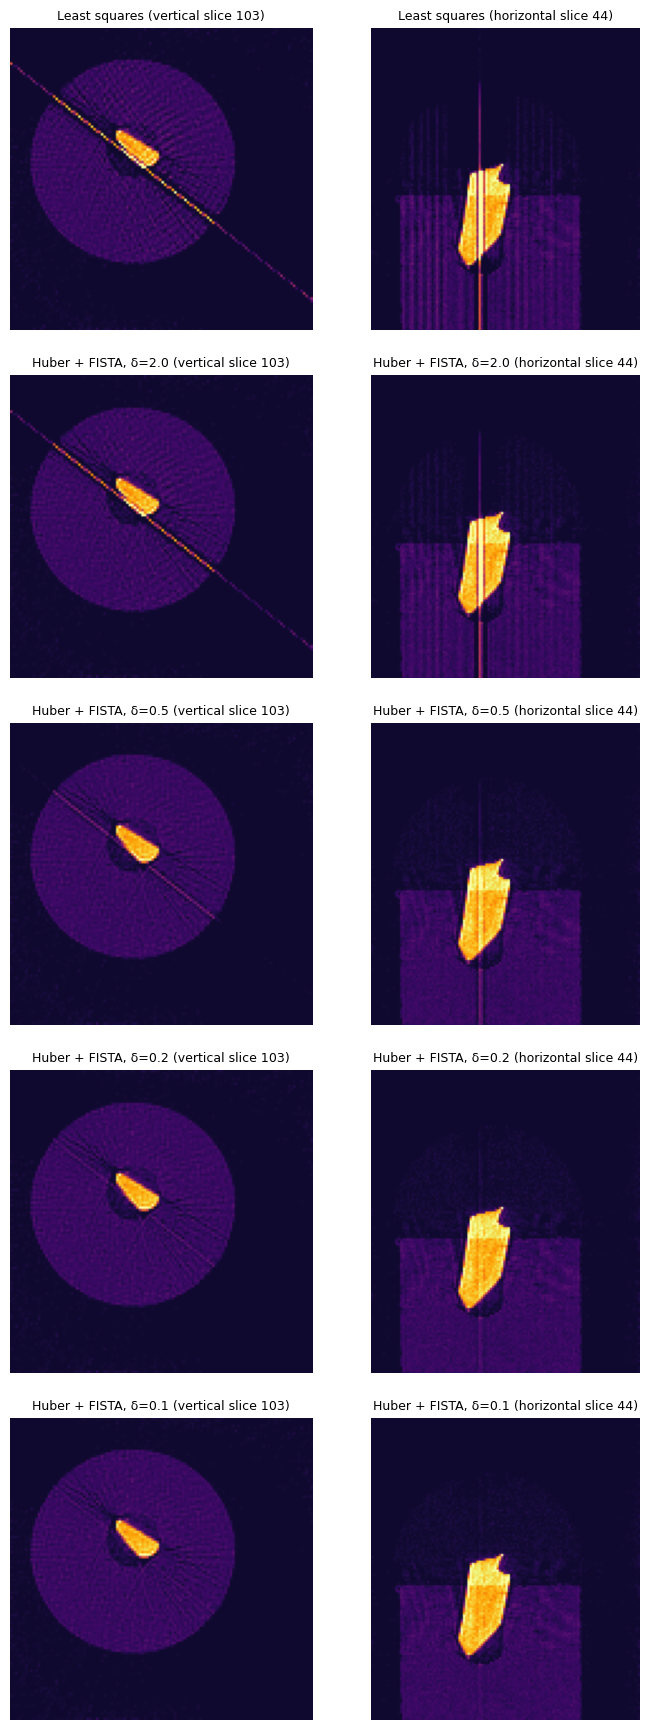

In [10]:
# Plotting
n_rows = 1 + len(huber_deltas)
n_cols = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7, 3.6 * n_rows),
    constrained_layout=False
)

title_fs = 9

# Least squares plots
axes[0, 0].imshow(recon_least_squares[103], cmap='inferno', vmin=ca1, vmax=ca2)
axes[0, 0].set_title("Least squares (vertical slice 103)", fontsize=title_fs)
axes[0, 0].axis("off")

axes[0, 1].imshow(recon_least_squares[:, :, 44], cmap='inferno', vmin=ca1, vmax=ca2)
axes[0, 1].set_title("Least squares (horizontal slice 44)", fontsize=title_fs)
axes[0, 1].axis("off")

# Huber plots
for i, delta in enumerate(huber_deltas, start=1):
    recon = recon_huber_dict[delta]

    axes[i, 0].imshow(recon[103], cmap='inferno', vmin=ca1, vmax=ca2)
    axes[i, 0].set_title(
        f"Huber + FISTA, δ={delta} (vertical slice 103)",
        fontsize=title_fs
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(recon[:, :, 44], cmap='inferno', vmin=ca1, vmax=ca2)
    axes[i, 1].set_title(
        f"Huber + FISTA, δ={delta} (horizontal slice 44)",
        fontsize=title_fs
    )
    axes[i, 1].axis("off")

# Reduce whitespace
plt.subplots_adjust(
    left=0.02, right=0.98,
    top=0.96, bottom=0.02,
    wspace=0.05, hspace=0.15
)

plt.show()


Huber loss is an outlier-robust alternative to L2 loss. In this example, we effectively removed the large outlier from the reconstruction. There are other real-world examples where the Huber loss might be useful.

In neutron CT datasets, detector images often contain bright spots caused by gamma rays. A preprocessing step is usually needed to remove these, but if remnants remain, the Huber loss could be beneficial.

Another application is tomographic reconstruction of powder diffraction spectra:
https://www.finden.co.uk/towards-artefact-free-x-ray-diffraction-tomography-images/

Streaky artifacts can appear in reconstructions when detector images contain single-crystal spots. In this case, there are two main options: explicitly model the single crystals, or remove the bright spots as a preprocessing step. Even when taking these precautions, streak artifacts may still appear in the reconstructions, and the Huber loss can, to some extent, mitigate them.